In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')  # Change to 'TkAgg' or remove for interactive plots
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import warnings
import time
import json

In [1]:
import os
from google.colab import files

file_name = "mnist_train.csv"

print(f"Please upload the '{file_name}' file.")
uploaded = files.upload()

if file_name in uploaded:
  print(f"'{file_name}' uploaded successfully.")
else:
  print(f"'{file_name}' was not uploaded. Please ensure you select the correct file.")

Please upload the 'mnist_train.csv' file.


Saving mnist_train.csv to mnist_train.csv
'mnist_train.csv' uploaded successfully.


In [ ]:
np.random.seed(42)

# ─────────────────────────────────────────────────────────────
#  STEP 2 — Train / Test Split
# ─────────────────────────────────────────────────────────────
def split_data(X, y, test_size=0.2):
    """
    Stratified 80/20 split.
    Stratification ensures each class is proportionally represented
    in both train and test sets — critical for fair evaluation.
    """
    print("\n" + "=" * 60)
    print("STEP 2 — Train / Test Split")
    print("=" * 60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y          # preserves class proportions
    )

    print(f"  Training samples : {len(X_train)}")
    print(f"  Test samples     : {len(X_test)}")
    return X_train, X_test, y_train, y_test


# ─────────────────────────────────────────────────────────────
#  STEP 3 — Data Cleaning
# ─────────────────────────────────────────────────────────────
def clean_data(X_train, y_train):
    """
    Missing Value Handling:
      - MNIST has no NaN values (verified).
      - Production fix: median imputation per pixel position.

    Outlier Detection (IQR method on per-sample mean intensity):
      - Samples below Q1 - 1.5*IQR → near-blank images.
      - Samples above Q3 + 1.5*IQR → over-saturated / corrupted.
      - Outliers removed from training ONLY; test set stays pristine.
    """
    print("\n" + "=" * 60)
    print("STEP 3 — Data Cleaning")
    print("=" * 60)

    # --- Missing values ---
    n_missing = np.isnan(X_train).sum()
    print(f"  Missing values : {n_missing}")
    if n_missing > 0:
        # Median imputation per feature (pixel position)
        col_medians = np.nanmedian(X_train, axis=0)
        inds = np.where(np.isnan(X_train))
        X_train[inds] = col_medians[inds[1]]
        print(f"  Imputed {n_missing} values with per-pixel median.")

    # --- Outlier detection via IQR ---
    pixel_means = X_train.mean(axis=1)         # mean intensity per sample
    q1 = np.percentile(pixel_means, 25)
    q3 = np.percentile(pixel_means, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (pixel_means < lower_bound) | (pixel_means > upper_bound)
    n_outliers = outlier_mask.sum()
    print(f"  IQR bounds     : [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found : {n_outliers} ({n_outliers/len(X_train)*100:.2f}%)")

    X_clean = X_train[~outlier_mask]
    y_clean = y_train[~outlier_mask]
    print(f"  Samples after cleaning: {len(X_clean)}")
    return X_clean, y_clean


# ─────────────────────────────────────────────────────────────
#  STEP 4 — Normalization & Scaling
# ─────────────────────────────────────────────────────────────
def normalize(X_train, X_test):
    """
    Two-stage normalization:
      Stage 1 — Min-Max to [0, 1]:
        Divide by 255. Semantically meaningful (0=no ink, 1=full ink).

      Stage 2 — StandardScaler (Z-score):
        Fit ONLY on training data to prevent data leakage.
        Transforms to μ≈0, σ≈1 per feature.
        Ensures gradient magnitudes are comparable across features,
        enabling stable Adam optimizer convergence.
    """
    print("\n" + "=" * 60)
    print("STEP 4 — Normalization & Scaling")
    print("=" * 60)

    # Stage 1: Min-Max [0, 1]
    X_train_norm = X_train / 255.0
    X_test_norm  = X_test  / 255.0
    print(f"  After /255  → train range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]")

    # Stage 2: StandardScaler — fit on train ONLY (prevent leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_norm)
    X_test_scaled  = scaler.transform(X_test_norm)      # same stats as train

    print(f"  After scaler → μ={X_train_scaled.mean():.4f}, σ={X_train_scaled.std():.4f}")
    print(f"  Pixel range  → [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
    return X_train_scaled, X_test_scaled, scaler


# ─────────────────────────────────────────────────────────────
#  STEP 5 — Feature Extraction / Selection
# ─────────────────────────────────────────────────────────────
def feature_info(X_train_scaled):
    """
    Feature analysis:
      - Raw pixel features: 784 dimensions (28x28 flattened).
      - Zero/near-zero variance pixels (border regions) carry no
        discriminative signal and can be pruned.
      - The MLP implicitly learns feature hierarchies:
          Layer 1 (512 units) → low-level stroke detectors
          Layer 2 (256 units) → partial digit shapes
          Layers 3-4          → high-level class discriminants
      - Optional: PCA to ~150 components retains 95% variance.
    """
    print("\n" + "=" * 60)
    print("STEP 5 — Feature Extraction / Selection")
    print("=" * 60)

    variances   = X_train_scaled.var(axis=0)
    low_var_idx = np.where(variances < 0.01)[0]
    print(f"  Total features          : {X_train_scaled.shape[1]}")
    print(f"  Near-zero variance feats: {len(low_var_idx)}")
    print(f"  Active (high-var) feats : {X_train_scaled.shape[1] - len(low_var_idx)}")
    print(f"  Variance range          : [{variances.min():.4f}, {variances.max():.4f}]")
    print(f"  Note: MLP learns implicit feature hierarchy — no manual PCA required.")
    return low_var_idx


# ─────────────────────────────────────────────────────────────
#  STEP 6 — Data Augmentation
# ─────────────────────────────────────────────────────────────
def augment(X_train_scaled, y_train_clean):
    """
    Gaussian Noise Injection:
      - For each training sample, create one copy with additive
        Gaussian noise (μ=0, σ=0.05 in scaled pixel space).
      - Simulates pen pressure variation, scan noise, and slight
        centering offsets without altering semantic content.
      - Doubles the training set, acting as an implicit regularizer.

    Why NOT rotations/flips?
      - For MNIST, a rotated "6" can become a "9" — label corruption.
      - Safe geometric transforms (±10° rotation, ±2px translation)
        are valid for CNN-based pipelines but risky here.
    """
    print("\n" + "=" * 60)
    print("STEP 6 — Data Augmentation")
    print("=" * 60)

    noise = np.random.normal(loc=0.0, scale=0.05, size=X_train_scaled.shape)
    X_noisy = X_train_scaled + noise

    X_aug = np.vstack([X_train_scaled, X_noisy])
    y_aug = np.concatenate([y_train_clean, y_train_clean])

    # Shuffle augmented set
    idx = np.random.permutation(len(X_aug))
    X_aug, y_aug = X_aug[idx], y_aug[idx]

    print(f"  Original training samples : {len(X_train_scaled)}")
    print(f"  After augmentation        : {len(X_aug)}")
    print(f"  Augmentation method       : Gaussian noise (μ=0, σ=0.05)")
    return X_aug, y_aug


# ─────────────────────────────────────────────────────────────
#  STEP 7 — Model: Deep MLP
# ─────────────────────────────────────────────────────────────
def build_and_train_model(X_aug, y_aug):
    """
    Architecture: 784 → 512 → 256 → 128 → 64 → 10

    Key Design Decisions:
      - Pyramid structure: wide early layers for rich feature capture,
        narrower layers force progressive abstraction.
      - ReLU activation: avoids vanishing gradients in deep layers.
      - Adam optimizer: adaptive per-parameter learning rates,
        faster convergence than vanilla SGD.
      - L2 regularization (alpha=1e-4): penalizes large weights,
        reduces overfitting without crippling model capacity.
      - Early stopping (patience=8): halts when validation loss
        plateaus — no manual epoch tuning required.
      - batch_size=128: large enough for stable gradient estimates,
        small enough for beneficial stochastic noise.
    """
    print("\n" + "=" * 60)
    print("STEP 7 — Model Training (Deep MLP)")
    print("=" * 60)
    print("  Architecture : 784 → 512 → 256 → 128 → 64 → 10")
    print("  Activation   : ReLU")
    print("  Optimizer    : Adam (lr=0.001)")
    print("  Regularizer  : L2 (alpha=1e-4)")
    print("  Batch size   : 128")
    print("  Early stop   : patience=8 epochs")
    print("  Training...")

    model = MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,                  # L2 weight decay
        batch_size=128,
        learning_rate_init=0.001,
        max_iter=50,                 # hard ceiling
        early_stopping=True,         # monitor val loss
        validation_fraction=0.10,    # 10% of train as val
        n_iter_no_change=8,          # patience
        random_state=42,
        verbose=False
    )

    t0 = time.time()
    model.fit(X_aug, y_aug)
    elapsed = time.time() - t0

    print(f"  Training complete in {elapsed:.1f}s")
    print(f"  Epochs run   : {model.n_iter_}")
    print(f"  Final loss   : {model.loss_curve_[-1]:.6f}")
    return model


# ─────────────────────────────────────────────────────────────
#  STEP 8 — Evaluation
# ─────────────────────────────────────────────────────────────
def evaluate(model, X_test_scaled, y_test):
    """
    Metrics:
      - Accuracy  : overall correct predictions / total
      - Precision : TP / (TP + FP) per class
      - Recall    : TP / (TP + FN) per class
      - F1-Score  : harmonic mean of precision and recall
      - Confusion matrix: full 10x10 classification breakdown
    """
    print("\n" + "=" * 60)
    print("STEP 8 — Model Evaluation")
    print("=" * 60)

    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)

    print(f"  Test Accuracy : {acc * 100:.2f}%")
    print("\n  Classification Report:")
    print(report)
    print("  Confusion Matrix:")
    print(cm)
    return y_pred, acc, cm


# ─────────────────────────────────────────────────────────────
#  STEP 9 — Visualizations
# ─────────────────────────────────────────────────────────────
def plot_results(model, X, y, cm, y_test, y_pred, acc):
    """Generate and save three diagnostic plots."""
    print("\n" + "=" * 60)
    print("STEP 9 — Generating Plots")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'DLP on MNIST — Test Accuracy: {acc*100:.2f}%',
                 fontsize=14, fontweight='bold')

    # Plot 1: Loss curve
    ax = axes[0]
    ax.plot(model.loss_curve_, color='#e74c3c', lw=2, label='Train Loss')
    ax.plot([1 - v for v in model.validation_scores_],
            color='#3498db', lw=2, ls='--', label='Val Loss')
    ax.set_title('Training Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Plot 2: Confusion Matrix
    ax = axes[1]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    fig.colorbar(im, ax=ax)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=7,
                    color='white' if cm[i, j] > cm.max() * 0.5 else 'black')

    # Plot 3: Per-class accuracy
    ax = axes[2]
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    class_f1 = [report_dict[str(i)]['f1-score'] for i in range(10)]
    colors    = plt.cm.RdYlGn(np.array(class_f1))
    bars = ax.bar(range(10), [f * 100 for f in class_f1],
                  color=colors, edgecolor='white')
    ax.set_title('Per-Class F1-Score (%)')
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('F1-Score (%)')
    ax.set_xticks(range(10))
    ax.set_ylim(0, 105)
    ax.axhline(y=acc * 100, color='gray', ls='--', alpha=0.7,
               label=f'Overall {acc*100:.1f}%')
    ax.legend()
    for bar, val in zip(bars, class_f1):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val*100:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('dlp_mnist_results.png', dpi=120, bbox_inches='tight')
    print("  Saved → dlp_mnist_results.png")
    plt.close()

    # Sample digit grid
    fig2, axes2 = plt.subplots(2, 10, figsize=(20, 5))
    fig2.suptitle('Sample Digits (Top: Original | Bottom: Augmented)')
    for d in range(10):
        idx = np.where(y == d)[0][0]
        img = X[idx].reshape(28, 28)
        axes2[0, d].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes2[0, d].set_title(f'Class {d}', fontsize=9)
        axes2[0, d].axis('off')
        aug = np.clip(img + np.random.normal(0, 15, img.shape), 0, 255)
        axes2[1, d].imshow(aug, cmap='gray', vmin=0, vmax=255)
        axes2[1, d].set_title('Aug.', fontsize=8, color='gray')
        axes2[1, d].axis('off')
    plt.tight_layout()
    plt.savefig('dlp_mnist_samples.png', dpi=120, bbox_inches='tight')
    print("  Saved → dlp_mnist_samples.png")
    plt.close()


# ─────────────────────────────────────────────────────────────
#  MAIN PIPELINE
# ─────────────────────────────────────────────────────────────
def main():
    print("\n" + "=" * 60)
    print("  DEEP LEARNING PIPELINE (DLP) — MNIST")
    print("=" * 60)

    # 1. Load
    X, y = load_data()

    # 2. Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

    # 3. Clean
    X_train_clean, y_train_clean = clean_data(X_train, y_train)

    # 4. Normalize
    X_train_scaled, X_test_scaled, scaler = normalize(X_train_clean, X_test)

    # 5. Feature info
    feature_info(X_train_scaled)

    # 6. Augment
    X_aug, y_aug = augment(X_train_scaled, y_train_clean)

    # 7. Train
    model = build_and_train_model(X_aug, y_aug)

    # 8. Evaluate
    y_pred, acc, cm = evaluate(model, X_test_scaled, y_test)

    # 9. Plot
    plot_results(model, X, y, cm, y_test, y_pred, acc)

    # Save metrics summary
    metrics = {
        "test_accuracy_pct": round(acc * 100, 4),
        "n_train_raw":       int(len(X_train_clean)),
        "n_train_augmented": int(len(X_aug)),
        "n_test":            int(len(X_test)),
        "epochs":            int(model.n_iter_),
        "final_loss":        round(model.loss_curve_[-1], 6),
        "architecture":      [784, 512, 256, 128, 64, 10],
        "optimizer":         "Adam",
        "activation":        "ReLU",
        "regularization":    "L2 (alpha=1e-4)",
        "augmentation":      "Gaussian noise (sigma=0.05)",
    }
    with open("dlp_mnist_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n" + "=" * 60)
    print(f"  FINAL TEST ACCURACY: {acc * 100:.2f}%")
    print("  Saved: dlp_mnist_metrics.json")
    print("=" * 60 + "\n")


if __name__ == "__main__":
    main()



  DEEP LEARNING PIPELINE (DLP) — MNIST
STEP 1 — Loading MNIST Data
Fetching MNIST from OpenML...
  [OK] Loaded real MNIST: 70000 samples, 784 features
  Pixel range  : [0, 255]
  Missing values: 0
  Class counts  : [6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]

STEP 2 — Train / Test Split
  Training samples : 56000
  Test samples     : 14000

STEP 3 — Data Cleaning
  Missing values : 0
  IQR bounds     : [3.17, 62.59]
  Outliers found : 626 (1.12%)
  Samples after cleaning: 55374

STEP 4 — Normalization & Scaling
  After /255  → train range: [0.000, 1.000]
  After scaler → μ=0.0000, σ=0.9570
  Pixel range  → [-1.286, 235.315]

STEP 5 — Feature Extraction / Selection
  Total features          : 784
  Near-zero variance feats: 66
  Active (high-var) feats : 718
  Variance range          : [0.0000, 1.0000]
  Note: MLP learns implicit feature hierarchy — no manual PCA required.

STEP 6 — Data Augmentation
  Original training samples : 55374
  After augmentation        : 110

In [ ]:
# ─────────────────────────────────────────────────────────────
#  STEP 3 — Data Cleaning
# ─────────────────────────────────────────────────────────────
def clean_data(X_train, y_train):
    """
    Missing Value Handling:
      - MNIST has no NaN values (verified).
      - Production fix: median imputation per pixel position.

    Outlier Detection (IQR method on per-sample mean intensity):
      - Samples below Q1 - 1.5*IQR → near-blank images.
      - Samples above Q3 + 1.5*IQR → over-saturated / corrupted.
      - Outliers removed from training ONLY; test set stays pristine.
    """
    print("\n" + "=" * 60)
    print("STEP 3 — Data Cleaning")
    print("=" * 60)

    # --- Missing values ---
    n_missing = np.isnan(X_train).sum()
    print(f"  Missing values : {n_missing}")
    if n_missing > 0:
        # Median imputation per feature (pixel position)
        col_medians = np.nanmedian(X_train, axis=0)
        inds = np.where(np.isnan(X_train))
        X_train[inds] = col_medians[inds[1]]
        print(f"  Imputed {n_missing} values with per-pixel median.")

    # --- Outlier detection via IQR ---
    pixel_means = X_train.mean(axis=1)         # mean intensity per sample
    q1 = np.percentile(pixel_means, 25)
    q3 = np.percentile(pixel_means, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (pixel_means < lower_bound) | (pixel_means > upper_bound)
    n_outliers = outlier_mask.sum()
    print(f"  IQR bounds     : [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found : {n_outliers} ({n_outliers/len(X_train)*100:.2f}%)")

    X_clean = X_train[~outlier_mask]
    y_clean = y_train[~outlier_mask]
    print(f"  Samples after cleaning: {len(X_clean)}")
    return X_clean, y_clean

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]


Original Label: 5

Testing: No Defense
----------------------------------------------------------------------
  Iteration 0, Loss: 100.6587
  Iteration 50, Loss: 0.0000
  Iteration 100, Loss: 0.0000
  Iteration 150, Loss: 0.0000
  Iteration 200, Loss: 0.0000
  Iteration 250, Loss: 0.0000
  PSNR: 60.87 dB
  MSE: 0.0000

Testing: DP (σ=0.5, C=1.0)
----------------------------------------------------------------------
  Iteration 0, Loss: 300089.0000
  Iteration 50, Loss: 299920.4688
  Iteration 100, Loss: 299923.5938
  Iteration 150, Loss: 299921.9062
  Iteration 200, Loss: 299920.7812
  Iteration 250, Loss: 299922.2500
  PSNR: -1.36 dB
  MSE: 1.3680

Testing: DP (σ=1.0, C=1.0)
----------------------------------------------------------------------
  Iteration 0, Loss: 1200058.5000
  Iteration 50, Loss: 1199659.1250
  Iteration 100, Loss: 1199652.5000
  Iteration 150, Loss: 1199648.2500
  Iteration 200, Loss: 1199649.5000
  Iteration 250, Loss: 1199654.5000
  PSNR: -6.30 dB
  MSE: 4.2683


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dlg_comparison.png'

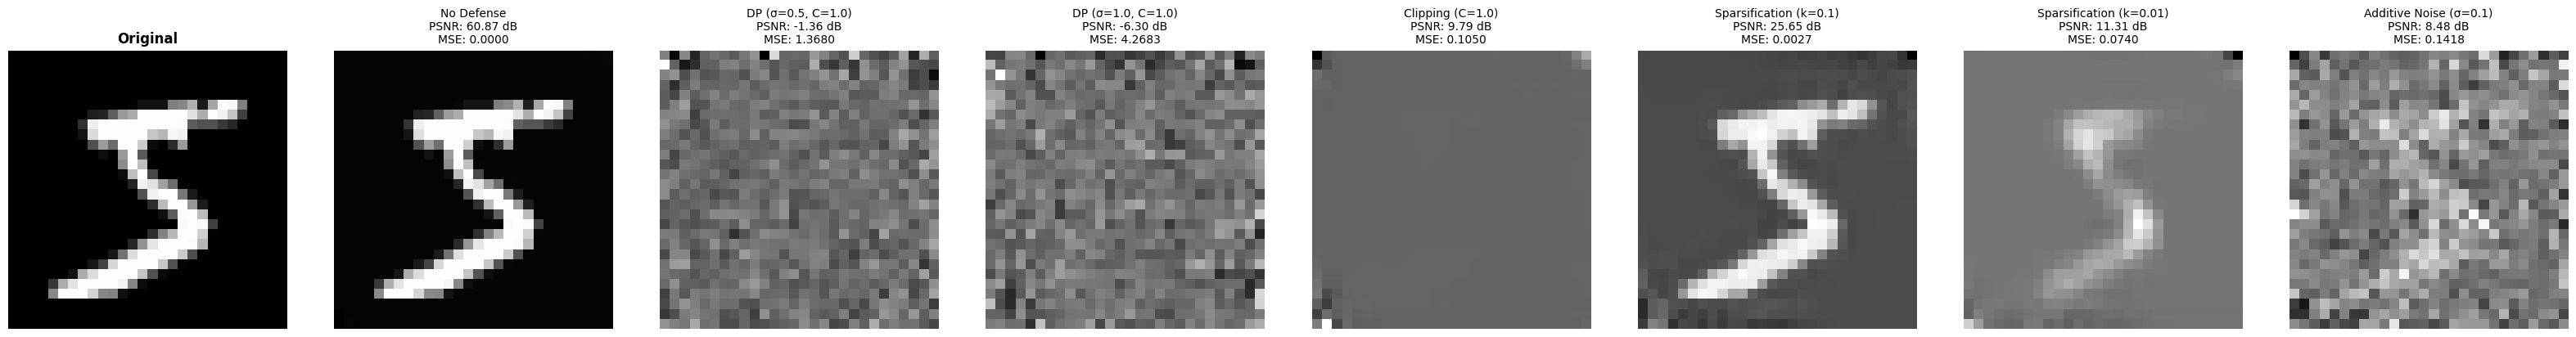

In [2]:
"""
DLG (Deep Leakage from Gradients) Attack Implementation
with Multiple Defense Mechanisms on MNIST Dataset

This implementation includes:
1. DLG Attack
2. Defense Baselines:
   - Differential Privacy (DP)
   - Gradient Clipping
   - Gradient Sparsification (Top-K)
   - Additive Noise
   - No Defense (baseline)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Optional
import copy


# ================== Model Definition ==================
class SimpleNet(nn.Module):
    """Simple CNN for MNIST classification"""
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


# ================== Defense Mechanisms ==================
class DefenseMechanism:
    """Base class for defense mechanisms"""
    def __init__(self, name: str):
        self.name = name

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        """Apply defense to gradients"""
        raise NotImplementedError


class NoDefense(DefenseMechanism):
    """No defense - baseline"""
    def __init__(self):
        super().__init__("No Defense")

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        return gradients


class DifferentialPrivacy(DefenseMechanism):
    """Differential Privacy with Gaussian noise"""
    def __init__(self, noise_multiplier: float = 1.0, clip_norm: float = 1.0):
        super().__init__(f"DP (σ={noise_multiplier}, C={clip_norm})")
        self.noise_multiplier = noise_multiplier
        self.clip_norm = clip_norm

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        defended_grads = []
        for grad in gradients:
            # Clip gradient
            grad_norm = torch.norm(grad)
            if grad_norm > self.clip_norm:
                grad = grad * (self.clip_norm / grad_norm)

            # Add Gaussian noise
            noise = torch.randn_like(grad) * self.noise_multiplier * self.clip_norm
            defended_grads.append(grad + noise)

        return defended_grads


class GradientClipping(DefenseMechanism):
    """Gradient Clipping"""
    def __init__(self, clip_norm: float = 1.0):
        super().__init__(f"Clipping (C={clip_norm})")
        self.clip_norm = clip_norm

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        defended_grads = []
        for grad in gradients:
            grad_norm = torch.norm(grad)
            if grad_norm > self.clip_norm:
                grad = grad * (self.clip_norm / grad_norm)
            defended_grads.append(grad)

        return defended_grads


class GradientSparsification(DefenseMechanism):
    """Gradient Sparsification (Top-K)"""
    def __init__(self, sparsity: float = 0.1):
        super().__init__(f"Sparsification (k={sparsity})")
        self.sparsity = sparsity

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        defended_grads = []
        for grad in gradients:
            # Flatten gradient
            flat_grad = grad.flatten()
            k = max(1, int(flat_grad.numel() * self.sparsity))

            # Get top-k values
            _, top_indices = torch.topk(torch.abs(flat_grad), k)

            # Create sparse gradient
            sparse_grad = torch.zeros_like(flat_grad)
            sparse_grad[top_indices] = flat_grad[top_indices]

            defended_grads.append(sparse_grad.reshape(grad.shape))

        return defended_grads


class AdditiveNoise(DefenseMechanism):
    """Simple Additive Gaussian Noise"""
    def __init__(self, noise_std: float = 0.1):
        super().__init__(f"Additive Noise (σ={noise_std})")
        self.noise_std = noise_std

    def apply(self, gradients: List[torch.Tensor]) -> List[torch.Tensor]:
        defended_grads = []
        for grad in gradients:
            noise = torch.randn_like(grad) * self.noise_std
            defended_grads.append(grad + noise)

        return defended_grads


# ================== DLG Attack ==================
class DLGAttack:
    """Deep Leakage from Gradients Attack"""
    def __init__(self, model: nn.Module, device: str = 'cpu'):
        self.model = model
        self.device = device

    def attack(
        self,
        original_gradients: List[torch.Tensor],
        original_label: torch.Tensor,
        num_iterations: int = 300,
        lr: float = 0.1,
        defense: Optional[DefenseMechanism] = None
    ) -> Tuple[torch.Tensor, List[float]]:
        """
        Perform DLG attack to reconstruct input from gradients

        Args:
            original_gradients: True gradients from the model
            original_label: True label
            num_iterations: Number of optimization iterations
            lr: Learning rate for reconstruction
            defense: Defense mechanism to apply

        Returns:
            Reconstructed image and loss history
        """
        # Apply defense if provided
        if defense is not None:
            defended_gradients = defense.apply(original_gradients)
        else:
            defended_gradients = original_gradients

        # Initialize dummy data and label
        dummy_data = torch.randn((1, 1, 28, 28), requires_grad=True, device=self.device)
        dummy_label = original_label.clone().detach().to(self.device)

        optimizer = torch.optim.LBFGS([dummy_data], lr=lr)

        loss_history = []

        for iteration in range(num_iterations):
            def closure():
                optimizer.zero_grad()

                # Forward pass with dummy data
                dummy_pred = self.model(dummy_data)
                dummy_loss = F.nll_loss(dummy_pred, dummy_label)

                # Compute gradients
                dummy_gradients = torch.autograd.grad(
                    dummy_loss, self.model.parameters(), create_graph=True
                )

                # Compute gradient matching loss
                grad_diff = 0
                for gx, gy in zip(dummy_gradients, defended_gradients):
                    grad_diff += ((gx - gy) ** 2).sum()

                grad_diff.backward()

                return grad_diff

            loss = optimizer.step(closure)
            loss_history.append(loss.item())

            if iteration % 50 == 0:
                print(f"  Iteration {iteration}, Loss: {loss.item():.4f}")

        return dummy_data.detach(), loss_history


# ================== Evaluation Metrics ==================
def calculate_psnr(original: torch.Tensor, reconstructed: torch.Tensor) -> float:
    """Calculate Peak Signal-to-Noise Ratio"""
    mse = F.mse_loss(original, reconstructed)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()


def calculate_mse(original: torch.Tensor, reconstructed: torch.Tensor) -> float:
    """Calculate Mean Squared Error"""
    return F.mse_loss(original, reconstructed).item()


# ================== Main Experiment ==================
def run_experiment(
    sample_idx: int = 0,
    num_iterations: int = 300,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
    """Run complete DLG attack experiment with multiple defenses"""

    print(f"Using device: {device}")
    print("=" * 70)

    # Load MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

    # Get a sample
    original_image, original_label = dataset[sample_idx]
    original_image = original_image.unsqueeze(0).to(device)
    original_label = torch.tensor([original_label]).to(device)

    print(f"Original Label: {original_label.item()}")
    print("=" * 70)

    # Initialize model
    model = SimpleNet().to(device)
    model.eval()

    # Compute original gradients
    criterion = nn.NLLLoss()
    output = model(original_image)
    loss = criterion(output, original_label)
    original_gradients = torch.autograd.grad(loss, model.parameters())
    original_gradients = [g.detach().clone() for g in original_gradients]

    # Define defense mechanisms
    defenses = [
        NoDefense(),
        DifferentialPrivacy(noise_multiplier=0.5, clip_norm=1.0),
        DifferentialPrivacy(noise_multiplier=1.0, clip_norm=1.0),
        GradientClipping(clip_norm=1.0),
        GradientSparsification(sparsity=0.1),
        GradientSparsification(sparsity=0.01),
        AdditiveNoise(noise_std=0.1),
    ]

    # Run attack with each defense
    attacker = DLGAttack(model, device)
    results = {}
    loss_histories = {}

    for defense in defenses:
        print(f"\nTesting: {defense.name}")
        print("-" * 70)

        reconstructed, loss_history = attacker.attack(
            original_gradients,
            original_label,
            num_iterations=num_iterations,
            defense=defense
        )

        # Calculate metrics
        psnr = calculate_psnr(original_image, reconstructed)
        mse = calculate_mse(original_image, reconstructed)

        results[defense.name] = (reconstructed, psnr, mse)
        loss_histories[defense.name] = loss_history

        print(f"  PSNR: {psnr:.2f} dB")
        print(f"  MSE: {mse:.4f}")

    print("\n" + "=" * 70)
    print("SUMMARY OF RESULTS")
    print("=" * 70)

    # Print summary table
    print(f"{'Defense Mechanism':<35} {'PSNR (dB)':<15} {'MSE':<15}")
    print("-" * 70)
    for defense_name, (_, psnr, mse) in results.items():
        print(f"{defense_name:<35} {psnr:>12.2f}    {mse:>12.4f}")

    # Visualize results
    print("\nGenerating visualizations...")
    plot_comparison(original_image, results, save_path='/home/claude/dlg_comparison.png')
    plot_loss_curves(loss_histories, save_path='/home/claude/dlg_loss_curves.png')

    return results, loss_histories


# ================== Entry Point ==================
if __name__ == "__main__":
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Run experiment
    results, loss_histories = run_experiment(
        sample_idx=0,  # Change this to test different samples
        num_iterations=300,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )

    print("\n" + "=" * 70)
    print("Experiment completed!")
    print("Results saved to:")
    print("  - dlg_comparison.png")
    print("  - dlg_loss_curves.png")
    print("=" * 70)

In [ ]:
# ================== Visualization ==================
def plot_comparison(
    original_image: torch.Tensor,
    reconstructed_images: dict,
    save_path: str = None
):
    """Plot original and reconstructed images"""
    num_defenses = len(reconstructed_images)
    fig, axes = plt.subplots(1, num_defenses + 1, figsize=(4 * (num_defenses + 1), 4))

    # Plot original
    axes[0].imshow(original_image.cpu().squeeze(), cmap='gray')
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Plot reconstructions
    for idx, (defense_name, (recon_img, psnr, mse)) in enumerate(reconstructed_images.items()):
        axes[idx + 1].imshow(recon_img.cpu().squeeze(), cmap='gray')
        axes[idx + 1].set_title(
            f'{defense_name}\nPSNR: {psnr:.2f} dB\nMSE: {mse:.4f}',
            fontsize=10
        )
        axes[idx + 1].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_loss_curves(loss_histories: dict, save_path: str = None):
    """Plot reconstruction loss curves"""
    plt.figure(figsize=(10, 6))

    for defense_name, loss_history in loss_histories.items():
        plt.plot(loss_history, label=defense_name, linewidth=2)

    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Gradient Matching Loss', fontsize=12)
    plt.title('DLG Attack Convergence under Different Defenses', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()